In [122]:
import pandas as pd
import pandas_ta as ta
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)
from sklearn import set_config

from lightgbm import LGBMClassifier
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')

set_config(display='diagram')

## Loading the Data

In [123]:
df = pd.read_csv('../raw_data/btc_1hour_cleaned.csv')

In [124]:
df.head(2)

,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
0,2018-01-01 00:00:00,13715.65,13715.65,13400.01,13529.01,443.356199,2018-01-01 00:59:59.999,5.993910e+06,5228,228.521921,3.090541e+06,0
1,2018-01-01 01:00:00,13528.99,13595.89,13155.38,13203.06,383.697006,2018-01-01 01:59:59.999,5.154522e+06,4534,180.840403,2.430449e+06,0


## Setting the correct formats and cleaning Dataframe

In [125]:
df['Open time'] = pd.to_datetime(df['Open time'])
df['Close time'] = pd.to_datetime(df['Close time'])

In [126]:
df = df.set_index('Open time')

In [127]:
df.head(3)

,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
Open time,,,,,,,,,,,
2018-01-01 00:00:00,13715.65,13715.65,13400.01,13529.01,443.356199,2018-01-01 00:59:59.999,5.993910e+06,5228,228.521921,3.090541e+06,0
2018-01-01 01:00:00,13528.99,13595.89,13155.38,13203.06,383.697006,2018-01-01 01:59:59.999,5.154522e+06,4534,180.840403,2.430449e+06,0
2018-01-01 02:00:00,13203.00,13418.43,13200.00,13330.18,429.064572,2018-01-01 02:59:59.999,5.710192e+06,4887,192.237935,2.558505e+06,0


In [128]:
df.shape

(71588, 11)

# Feature Engineering

In [129]:
# ROC — Rate of Change
def compute_roc(df):
    df['roc_10'] = df['Close'].pct_change(periods=10)
    df['roc_21'] = df['Close'].pct_change(periods=21)
    return df

# MACD Histogram
def compute_macd(df):
    macd = ta.macd(df['Close'], fast=12, slow=26, signal=9)
    df['macd_histogram'] = macd['MACDh_12_26_9']
    return df

# ADX — used as feature AND for regime detection (execution layer)
def compute_adx(df):
    df['adx'] = ta.adx(df['High'], df['Low'], df['Close'], length=14)['ADX_14']
    return df

# RSI 14
def compute_rsi_14(df):
    df['rsi_14'] = ta.rsi(df['Close'], length=14)
    return df

# RSI divergence
def compute_rsi_div(df):

    df['price_high'] = df['Close'].rolling(14).max()
    df['price_low']  = df['Close'].rolling(14).min()
    df['rsi_high']   = df['rsi_14'].rolling(14).max()
    df['rsi_low']    = df['rsi_14'].rolling(14).min()

    bearish_div = (df['Close'] == df['price_high']) & (df['rsi_14'] < df['rsi_high'])
    bullish_div = (df['Close'] == df['price_low'])  & (df['rsi_14'] > df['rsi_low'])

    df['rsi_divergence'] = 0
    df.loc[bullish_div, 'rsi_divergence'] = 1
    df.loc[bearish_div, 'rsi_divergence'] = -1

    df.drop(columns=['price_high', 'price_low', 'rsi_high', 'rsi_low'], inplace=True)

    return df

# OBV Change (10 bars)
def compute_obv(df):
    direction = df['Close'].diff(1).apply(lambda x: 1 if x > 0 else (-1 if x < 0 else 0))
    obv = (df['Volume'] * direction).cumsum()
    df['obv_change'] = obv.diff(10)
    return df

# Volume ROC (10 bars)
def compute_vol_roc(df):
    df['volume_roc'] = df['Volume'].pct_change(periods=10)
    return df

# Boilinger bandwidth
def compute_boilinger(df):

    # Upper and Lower Band

    window = 20
    num_std = 2

    # 3. Calculate the Simple Moving Average (SMA_20)
    df['sma_20'] = df['Close'].rolling(window=window).mean()

    # 4. Calculate the Standard Deviation (sigma)
    df['sigma'] = df['Close'].rolling(window=window).std()

    # 5. Calculate the Upper Band
    # Formula: SMA + (2 * sigma)
    df['upper_band'] = df['sma_20'] + (num_std * df['sigma'])

    # 6. Calculate the Lower Band
    # Formula: SMA - (2 * sigma)
    df['lower_band'] = df['sma_20'] - (num_std * df['sigma'])

    # 7. Calculate the Bandwidth
    # Formula: (Upper - Lower) / SMA
    df['bandwidth'] = (df['upper_band'] - df['lower_band']) / df['sma_20']

    return df

# ATR (Average-True-Return)
def  compute_atr(df):
    df['atr_14'] = ta.atr(df['High'], df['Low'], df['Close'], length=14)
    return df

# NATR — Normalised ATR
def compute_natr(df):
    df['natr'] = ta.natr(df['High'], df['Low'], df['Close'], length=14)
    return df


# SMA 50 and SMA 200 — regime detection only, NOT in feature matrix X
def compute_regime(df):
    df['sma_50']  = df['Close'].rolling(50).mean()
    df['sma_200'] = df['Close'].rolling(200).mean()
    df['regime']  = (df['sma_50'] > df['sma_200']).astype(int).replace(0, -1)
    return df


def feature_pipeline(df):
    steps = [
        compute_roc,
        compute_macd,
        compute_adx,
        compute_rsi_14,
        compute_rsi_div,
        compute_obv,
        compute_vol_roc,
        compute_boilinger,
        compute_atr,
        compute_natr,
        compute_regime,    # execution layer only — does NOT go into X
    ]
    for step in steps:
        df = step(df)
    return df


df = feature_pipeline(df)

print(f"Shape after feature engineering: {df.shape}")
df.head(3)

Shape after feature engineering: (71588, 29)


,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,...,sma_20,sigma,upper_band,lower_band,bandwidth,atr_14,natr,sma_50,sma_200,regime
Open time,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,13715.65,13715.65,13400.01,13529.01,443.356199,2018-01-01 00:59:59.999,5.993910e+06,5228,228.521921,3.090541e+06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
2018-01-01 01:00:00,13528.99,13595.89,13155.38,13203.06,383.697006,2018-01-01 01:59:59.999,5.154522e+06,4534,180.840403,2.430449e+06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1
2018-01-01 02:00:00,13203.00,13418.43,13200.00,13330.18,429.064572,2018-01-01 02:59:59.999,5.710192e+06,4887,192.237935,2.558505e+06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1


# Target labeling

In [130]:
# Lookahead window - change this value to test different horizons
N = 5

# Step 1 - Forward return
df['forward_return'] = df['Close'].pct_change(periods=N).shift(-N)

In [131]:
# Step 2 - Binary Label
df['label'] = (df['forward_return'] > 0).astype(int)
# 1 - BUY, 0 - SELL

In [132]:
df.head(10)

,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,...,upper_band,lower_band,bandwidth,atr_14,natr,sma_50,sma_200,regime,forward_return,label
Open time,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,13715.65,13715.65,13400.01,13529.01,443.356199,2018-01-01 00:59:59.999,5.993910e+06,5228,228.521921,3.090541e+06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,0.002216,1
2018-01-01 01:00:00,13528.99,13595.89,13155.38,13203.06,383.697006,2018-01-01 01:59:59.999,5.154522e+06,4534,180.840403,2.430449e+06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,0.043728,1
2018-01-01 02:00:00,13203.00,13418.43,13200.00,13330.18,429.064572,2018-01-01 02:59:59.999,5.710192e+06,4887,192.237935,2.558505e+06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,0.018017,1
2018-01-01 03:00:00,13330.26,13611.27,13290.00,13410.03,420.087030,2018-01-01 03:59:59.999,5.657448e+06,4789,137.918407,1.858041e+06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,0.006708,1
2018-01-01 04:00:00,13434.98,13623.29,13322.15,13601.01,340.807329,2018-01-01 04:59:59.999,4.588047e+06,4563,172.957635,2.328058e+06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,0.001175,1
2018-01-01 05:00:00,13615.20,13699.00,13526.50,13558.99,404.229046,2018-01-01 05:59:59.999,5.499055e+06,5086,142.331058,1.935710e+06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,0.000813,1
2018-01-01 06:00:00,13539.00,13800.00,13510.00,13780.41,264.989684,2018-01-01 06:59:59.999,3.613408e+06,4072,126.077500,1.718753e+06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,-0.040627,0
2018-01-01 07:00:00,13780.00,13818.55,13555.02,13570.35,292.188777,2018-01-01 07:59:59.999,4.002026e+06,4340,147.150029,2.016275e+06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,-0.029323,0
2018-01-01 08:00:00,13569.98,13735.24,13400.00,13499.99,271.813553,2018-01-01 08:59:59.999,3.681944e+06,3733,122.809696,1.664737e+06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,-0.035777,0


In [133]:
df.shape

(71588, 31)

In [134]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Close time',
       'Quote asset volume', 'Number of trades', 'Taker buy base asset volume',
       'Taker buy quote asset volume', 'Ignore', 'roc_10', 'roc_21',
       'macd_histogram', 'adx', 'rsi_14', 'rsi_divergence', 'obv_change',
       'volume_roc', 'sma_20', 'sigma', 'upper_band', 'lower_band',
       'bandwidth', 'atr_14', 'natr', 'sma_50', 'sma_200', 'regime',
       'forward_return', 'label'],
      dtype='str')

## Creating lags

In [ ]:
# 1. Setup definitions
N_lags = 5
feature_cols = ['Volume','roc_10', 'roc_21', 'macd_histogram', 'adx', 'rsi_14', 'rsi_divergence', 'obv_change',
                'volume_roc', 'bandwidth', 'atr_14', 'natr']

# 2. CREATE the lags (The missing step!)
lag_list = []
for col in feature_cols:
    for lag in range(1, N_lags + 1):
        lag_series = df[col].shift(lag).rename(f'{col}_lag{lag}')
        lag_list.append(lag_series)

# Combine them into the dataframe all at once
df = pd.concat([df] + lag_list, axis=1)

# 3. Define the list of all created lag names for reference
all_lag_cols = [f'{col}_lag{i}' for col in feature_cols for i in range(1, N_lags + 1)]

# 4. Now drop NaNs (since the columns actually exist now)
df = df.dropna(subset=feature_cols + all_lag_cols + ['label'])

# 5. Define Feature matrix and target
X_cols = feature_cols + all_lag_cols
X = df[X_cols]
y = df['label']

In [136]:
X.shape, y.shape

((71550, 72), (71550,))

# Cross Validating the Model

## Holdout Method

In [137]:
gap_size = 24

split_idx = int(len(X) * 0.80)

X_train   = X.iloc[:split_idx]
X_holdout = X.iloc[split_idx + gap_size:]
y_train   = y.iloc[:split_idx]
y_holdout = y.iloc[split_idx + gap_size:]

print("=" * 55)
print(f"X_train   shape: {X_train.shape}")
print(f"X_holdout shape: {X_holdout.shape}")
print("=" * 55)
print(f"Train period:   {X_train.index[0].date()}  →  {X_train.index[-1].date()}")
print(f"Holdout period: {X_holdout.index[0].date()}  →  {X_holdout.index[-1].date()}")
print("=" * 55)
print(f"Train BUY ratio:   {y_train.mean():.1%}")
print(f"Holdout BUY ratio: {y_holdout.mean():.1%}")

X_train   shape: (57240, 72)
X_holdout shape: (14286, 72)
Train period:   2018-01-02  →  2024-07-19
Holdout period: 2024-07-20  →  2026-03-07
Train BUY ratio:   51.3%
Holdout BUY ratio: 51.0%


## Pipeline

In [138]:
n_flat = (y_train == 0).sum()
n_buy  = (y_train == 1).sum()
scale_pos_weight = n_flat / n_buy

print(f"FLAT (0): {n_flat:,}  |  BUY (1): {n_buy:,}")
print(f"scale_pos_weight: {scale_pos_weight:.3f}")
print(f"→ BUY signals weighted {scale_pos_weight:.1f}x heavier than FLAT")

FLAT (0): 27,859  |  BUY (1): 29,381
scale_pos_weight: 0.948
→ BUY signals weighted 0.9x heavier than FLAT


In [139]:
pipe = Pipeline([
    ('model', LGBMClassifier(
        objective        = 'binary',
        boosting_type    = 'gbdt',
        learning_rate    = 0.05,
        n_estimators     = 500,
        max_depth        = 5,
        num_leaves       = 15,
        min_child_samples = 20,
        reg_alpha        = 0.01,
        reg_lambda       = 0.01,
        colsample_bytree = 0.7,
        scale_pos_weight = scale_pos_weight,
        random_state     = 42,
        verbose          = -1
    ))
])

# Pipeline diagram — Le Wagon standard
from sklearn import set_config
set_config(display='diagram')
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,boosting_type,'gbdt'
,num_leaves,15
,max_depth,5
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,'binary'


## Walk-Forward Validation

In [140]:
tscv = TimeSeriesSplit(n_splits=5, gap=24)

# Storage
fold_metrics      = []
fold_train_scores = []
fold_val_scores   = []
all_predictions   = []

# ✅ Change 8: measure total training time
total_start = time.time()

print("Walk-Forward Cross-Validation")
print("=" * 75)

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):

    fold_start = time.time()    # ✅ Change 8: per-fold timer

    X_fold_train = X_train.iloc[train_idx]
    y_fold_train = y_train.iloc[train_idx]
    X_fold_val   = X_train.iloc[val_idx]
    y_fold_val   = y_train.iloc[val_idx]

    # Fit pipeline on this fold's training data
    pipe.fit(
    X_fold_train, y_fold_train,
    model__eval_set=[(X_fold_val, y_fold_val)],
    model__eval_metric='binary_logloss',
    model__callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

    # Predictions on train and val
    y_fold_train_pred = pipe.predict(X_fold_train)
    y_fold_val_pred   = pipe.predict(X_fold_val)

    # ✅ Change 9: compute metrics per fold
    train_f1 = f1_score(y_fold_train, y_fold_train_pred, zero_division=0)
    val_prec = precision_score(y_fold_val, y_fold_val_pred, zero_division=0)
    val_rec  = recall_score(y_fold_val, y_fold_val_pred, zero_division=0)
    val_f1   = f1_score(y_fold_val, y_fold_val_pred, zero_division=0)

    fold_train_scores.append(train_f1)
    fold_val_scores.append(val_f1)

    fold_elapsed = time.time() - fold_start

    fold_metrics.append({
        'Fold'          : fold + 1,
        'Train bars'    : len(train_idx),
        'Val bars'      : len(val_idx),
        'Train F1'      : round(train_f1, 3),
        'Val Precision' : round(val_prec, 3),
        'Val Recall'    : round(val_rec, 3),
        'Val F1'        : round(val_f1, 3),
        'Time (s)'      : round(fold_elapsed, 1)    # ✅ Change 8
    })

    # Collect predictions for later analysis
    fold_df = y_fold_val.copy().to_frame(name='y_true')
    fold_df['y_pred'] = y_fold_val_pred
    fold_df['fold']   = fold + 1
    all_predictions.append(fold_df)

    print(
        f"Fold {fold+1} "
        f"| Train: {len(train_idx):>6,} bars "
        f"| Val: {len(val_idx):>5,} bars "
        f"| Train F1: {train_f1:.3f} "
        f"| Val F1: {val_f1:.3f} "
        f"| Time: {fold_elapsed:.1f}s"    # ✅ Change 8
    )

# ✅ Change 8: total training time
total_elapsed = time.time() - total_start
print("=" * 75)
print(f"Total CV time: {total_elapsed:.1f}s  ({total_elapsed / 60:.1f} min)")

Walk-Forward Cross-Validation
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[30]	valid_0's binary_logloss: 0.688873
Fold 1 | Train:  9,516 bars | Val: 9,540 bars | Train F1: 0.628 | Val F1: 0.539 | Time: 0.6s
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[46]	valid_0's binary_logloss: 0.688917
Fold 2 | Train: 19,056 bars | Val: 9,540 bars | Train F1: 0.645 | Val F1: 0.573 | Time: 1.0s
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[39]	valid_0's binary_logloss: 0.690573
Fold 3 | Train: 28,596 bars | Val: 9,540 bars | Train F1: 0.650 | Val F1: 0.591 | Time: 1.3s
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[52]	valid_0's binary_logloss: 0.690523
Fold 4 | Train: 38,136 bars | Val: 9,540 bars | Train F1: 0.621 | Val F1: 0.600 | Time: 1.7s
Training until validation scores don't improve for 50 

In [141]:
metrics_df = pd.DataFrame(fold_metrics).set_index('Fold')

print("Metrics per Fold")
print("=" * 75)
display(metrics_df)

print("\nSummary (mean ± std across folds)")
print("-" * 45)
print(f"Val Precision: {metrics_df['Val Precision'].mean():.3f} ± {metrics_df['Val Precision'].std():.3f}")
print(f"Val Recall:    {metrics_df['Val Recall'].mean():.3f} ± {metrics_df['Val Recall'].std():.3f}")
print(f"Val F1:        {metrics_df['Val F1'].mean():.3f} ± {metrics_df['Val F1'].std():.3f}")

Metrics per Fold


,Train bars,Val bars,Train F1,Val Precision,Val Recall,Val F1,Time (s)
Fold,,,,,,,
1,9516,9540,0.628,0.566,0.515,0.539,0.6
2,19056,9540,0.645,0.575,0.571,0.573,1.0
3,28596,9540,0.650,0.521,0.682,0.591,1.3
4,38136,9540,0.621,0.523,0.704,0.600,1.7
5,47676,9540,0.595,0.570,0.484,0.524,2.3



Summary (mean ± std across folds)
---------------------------------------------
Val Precision: 0.551 ± 0.027
Val Recall:    0.591 ± 0.098
Val F1:        0.565 ± 0.033


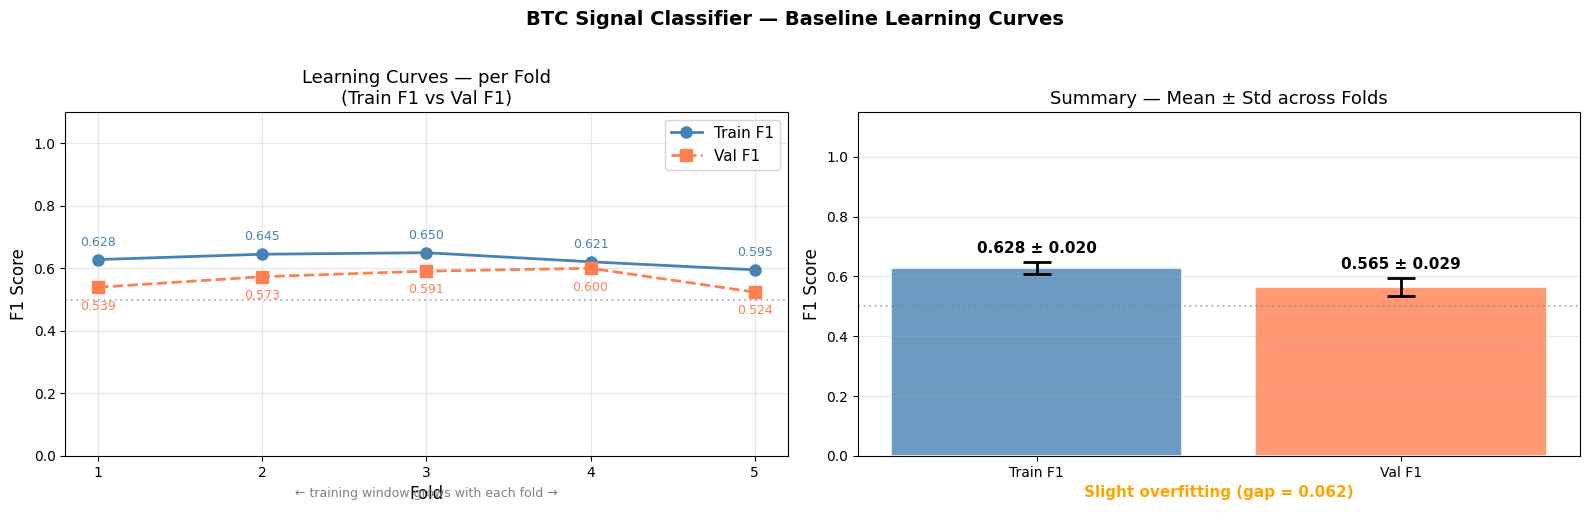

Train-Val gap: 0.062  →  Slight overfitting (gap = 0.062)


In [142]:
ig, axes = plt.subplots(1, 2, figsize=(16, 5))

folds = list(range(1, len(fold_train_scores) + 1))


# ── Plot 1: Train F1 vs Val F1 per fold ────────────────────────────────────
ax1 = axes[0]

ax1.plot(folds, fold_train_scores,
         'o-', color='steelblue', linewidth=2, markersize=8, label='Train F1')
ax1.plot(folds, fold_val_scores,
         's--', color='coral', linewidth=2, markersize=8, label='Val F1')

for i, (tr, va) in enumerate(zip(fold_train_scores, fold_val_scores)):
    ax1.annotate(f'{tr:.3f}', (i + 1, tr),
                 textcoords='offset points', xytext=(0, 10),
                 ha='center', fontsize=9, color='steelblue')
    ax1.annotate(f'{va:.3f}', (i + 1, va),
                 textcoords='offset points', xytext=(0, -16),
                 ha='center', fontsize=9, color='coral')

ax1.set_xlabel('Fold', fontsize=12)
ax1.set_ylabel('F1 Score', fontsize=12)
ax1.set_title('Learning Curves — per Fold\n(Train F1 vs Val F1)', fontsize=13)
ax1.set_xticks(folds)
ax1.set_ylim(0, 1.1)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='Random baseline')
ax1.annotate('← training window grows with each fold →',
             xy=(0.5, -0.12), xycoords='axes fraction',
             ha='center', fontsize=9, color='gray')


# ── Plot 2: Summary — mean ± std across folds ──────────────────────────────
ax2 = axes[1]

mean_train = np.mean(fold_train_scores)
std_train  = np.std(fold_train_scores)
mean_val   = np.mean(fold_val_scores)
std_val    = np.std(fold_val_scores)

bars = ax2.bar(
    ['Train F1', 'Val F1'],
    [mean_train, mean_val],
    yerr=[std_train, std_val],
    color=['steelblue', 'coral'],
    alpha=0.8,
    capsize=10,
    edgecolor='white',
    linewidth=1.5,
    error_kw={'elinewidth': 2, 'ecolor': 'black', 'capthick': 2}
)

for bar, mean, std in zip(bars, [mean_train, mean_val], [std_train, std_val]):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        mean + std + 0.02,
        f'{mean:.3f} ± {std:.3f}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax2.set_ylabel('F1 Score', fontsize=12)
ax2.set_title('Summary — Mean ± Std across Folds', fontsize=13)
ax2.set_ylim(0, 1.15)
ax2.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)
ax2.grid(True, alpha=0.3, axis='y')

# Overfitting verdict
gap = mean_train - mean_val
if gap > 0.15:
    verdict = f'Overfitting detected (gap = {gap:.3f})'
    color   = 'red'
elif gap > 0.05:
    verdict = f'Slight overfitting (gap = {gap:.3f})'
    color   = 'orange'
else:
    verdict = f'Good generalisation (gap = {gap:.3f})'
    color   = 'green'

ax2.text(0.5, -0.12, verdict,
         transform=ax2.transAxes,
         ha='center', fontsize=11, color=color, fontweight='bold')

plt.suptitle('BTC Signal Classifier — Baseline Learning Curves',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('learning_curves_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Train-Val gap: {gap:.3f}  →  {verdict}")

At 70.0% Precision, the Recall is 14.69%
The target threshold is 0.55


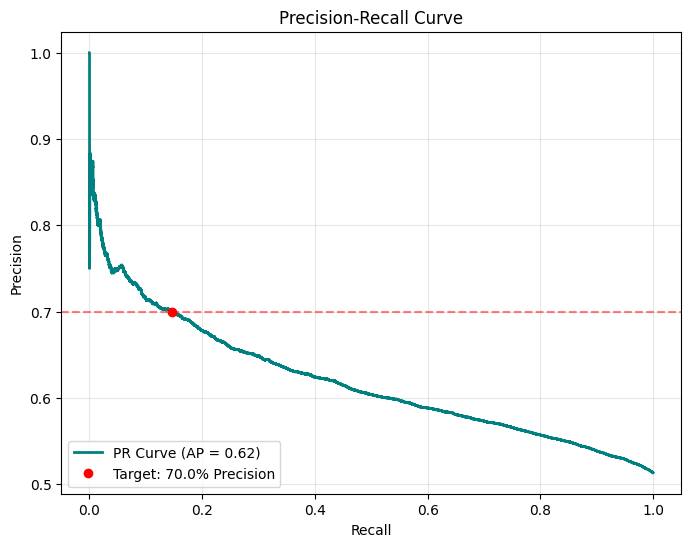

In [143]:
from sklearn.metrics import precision_recall_curve, average_precision_score

y_scores = pipe.predict_proba(X_train)[:,1]

precision, recall, thresholds = precision_recall_curve(y_train, y_scores)
avg_precision = average_precision_score(y_train, y_scores)

# 3. Find the recall when precision is at least 60%
target_precision = 0.70
# We find indices where precision is >= 60% and take the one with the highest recall
indices = np.where(precision >= target_precision)[0]
if indices.size > 0:
    best_index = indices[np.argmax(recall[indices])]
    target_recall = recall[best_index]
    target_threshold = thresholds[min(best_index, len(thresholds)-1)]
    print(f"At {target_precision*100}% Precision, the Recall is {target_recall*100:.2f}%")
    print(f"The target threshold is {target_threshold:.2f}")
else:
    print("Precision target never reached.")

# 4. Plotting
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='teal', lw=2, label=f'PR Curve (AP = {avg_precision:.2f})')

# Add the target threshold point
plt.plot(target_recall, target_precision, 'ro', label=f'Target: {target_precision*100}% Precision')
plt.axhline(y=target_precision, color='r', linestyle='--', alpha=0.5)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.show()

In [144]:
# 1. Final Fit on the entire Training Set
# (Now that we've tuned it with CV, we use all 80% of data to train)
pipe.fit(X_train, y_train)

# 2. Predict on the 20% Holdout Set
y_probs = pipe.predict_proba(X_holdout)[:, 1]
y_pred = (y_probs >= target_threshold).astype(int)

# 3. Generate the Report
report = classification_report(y_holdout, y_pred, target_names=['FLAT', 'BUY'])
print("Final Evaluation on Holdout Set (2024-2026):")
print("-" * 60)
print(report)


Final Evaluation on Holdout Set (2024-2026):
------------------------------------------------------------
              precision    recall  f1-score   support

        FLAT       0.50      0.72      0.59      6998
         BUY       0.53      0.31      0.40      7288

    accuracy                           0.51     14286
   macro avg       0.52      0.51      0.49     14286
weighted avg       0.52      0.51      0.49     14286



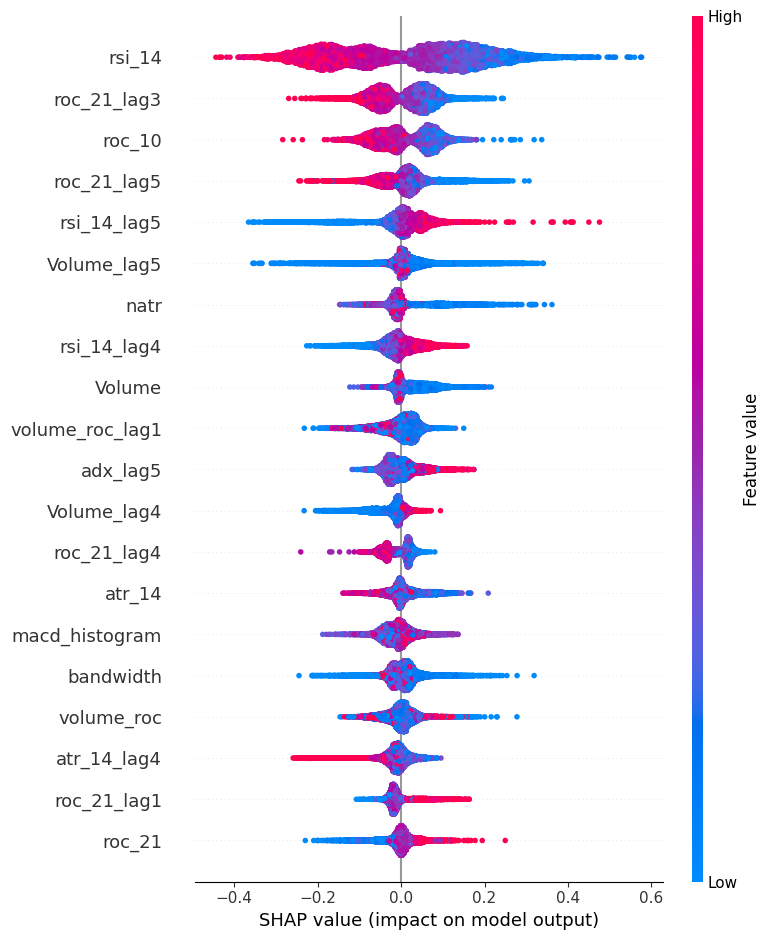

In [145]:
import shap

# 1. Extract the model
model = pipe.named_steps['model']

# 2. Use TreeExplainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_holdout)

# 3. Handle the "List vs Matrix" logic
# If SHAP returns a list (usually [neg_class, pos_class]), take the second one.
# If it returns a single matrix, use it directly.
if isinstance(shap_values, list):
    val_to_plot = shap_values[1]
else:
    val_to_plot = shap_values

# 4. Plot
shap.summary_plot(val_to_plot, X_holdout)